In [2]:
import sys
sys.path.append('../code')
sys.path.append('../externals/SIMNETS-Python/')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans, SpectralClustering

from tqdm import tqdm

import simnets

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [3]:
data_path =  '/users/ntolley/data/ntolley/dendractor/memory_permutations/random_initialization'

file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

  0%|          | 0/12 [00:00<?, ?it/s]ERROR:2025-06-14 11:01:09,019:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 135, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 230, in initialize
    _check_cuda_versions(raise_on_first

In [4]:
print(list(random_init_dict.keys()))

['cuedendampa_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendnmda', 'cuedendampa_Esomanmda_Edendampa', 'cuedendnmda_Esomaampa_Edendampa', 'cuedendnmda_Esomaampa_Edendnmda', 'cuedendnmda_Esomanmda_Edendampa', 'cuesomaampa_Esomaampa_Edendampa', 'cuesomaampa_Esomaampa_Edendnmda', 'cuesomaampa_Esomanmda_Edendampa', 'cuesomanmda_Esomaampa_Edendampa', 'cuesomanmda_Esomaampa_Edendnmda', 'cuesomanmda_Esomanmda_Edendampa']


In [30]:
t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(0 / downsample_factor)

config_names = [
    'cuedendnmda_Esomaampa_Edendampa',
    'cuedendampa_Esomaampa_Edendampa',
    'cuesomanmda_Esomaampa_Edendampa', 
    'cuesomaampa_Esomaampa_Edendampa', 
    ]

name = config_names[0]
res_dict = random_init_dict[name]

output_array = res_dict['output_array']
targets = res_dict['targets']
targets_stacked = res_dict['targets_stacked']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]

In [31]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)

num_train_sims = 9

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_train_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_train_sims)])
model.fit(rate_fit, target_fit)

for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])

    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list[:num_train_sims])
print(error_list[num_train_sims:])


# Data used for plotting
y_val = list()
for cond_idx in range(num_cond):
    sim_idx = num_cond * num_train_sims
    x_val = output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :]
    y_val.append(model.predict(x_val[burn_in:, :].T))


[np.float64(0.631252727237846), np.float64(0.5201714427537312), np.float64(0.5405059200196197), np.float64(0.7946967289514654), np.float64(0.47899778292469153), np.float64(0.6430789395791168), np.float64(0.5341185893201619), np.float64(0.5441152650391775), np.float64(0.5813368058283557)]
[np.float64(0.8488396154096995)]


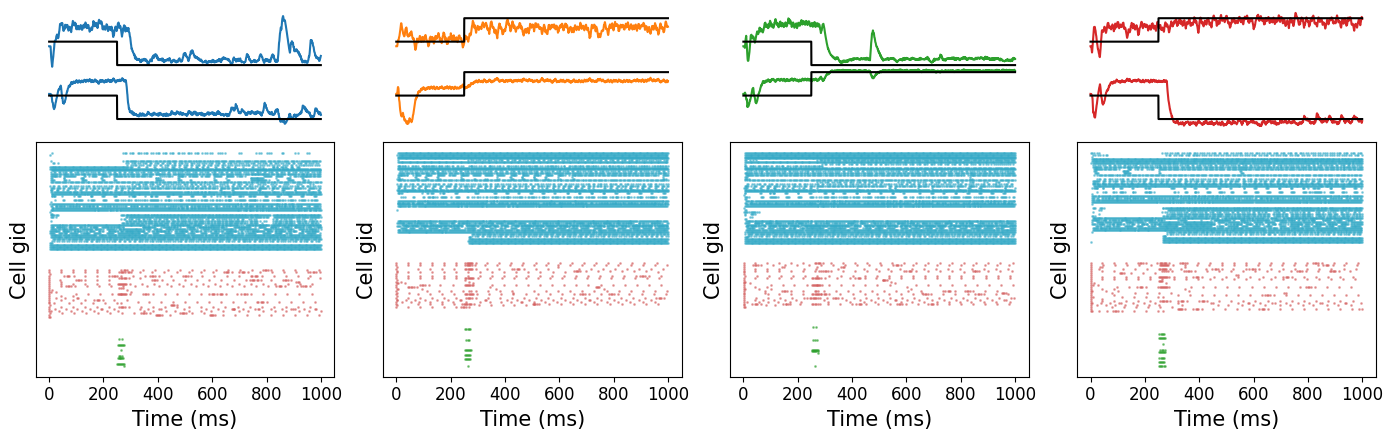

In [42]:
color_dict = {
        'cuedendnmda_Esomaampa_Edendampa': 'C0',
        'cuedendampa_Esomaampa_Edendampa': 'lightsteelblue',
        'cuesomanmda_Esomaampa_Edendampa': 'C3',
        'cuesomaampa_Esomaampa_Edendampa': 'darkorange'
}

legend_dict = {
        'cuedendnmda_Esomaampa_Edendampa': '$\\rm NMDA_{dend}$',
        'cuedendampa_Esomaampa_Edendampa': '$\\rm AMPA_{dend}$',
        'cuesomanmda_Esomaampa_Edendampa': '$\\rm NMDA_{soma}$',
        'cuesomaampa_Esomaampa_Edendampa': '$\\rm AMPA_{soma}$'
}

fontsize = 15
ticksize = 12
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c', 'noise_E': 'k', 'noise_I': 'k' }

fig, ax = plt.subplots(2, 4, height_ratios=[0.5, 1], figsize=(14,4.5))
for plot_idx, sim_idx in enumerate(range(num_cond)):


    pred_offset = 2.3
    # Plot response pred
    plt.subplot(2,4, plot_idx+1)
    plt.plot(time_vec, y_val[plot_idx][:-1, 0] + pred_offset, color=f'C{plot_idx}')
    plt.plot(time_vec, targets_stacked[plot_idx, 0, :-1].T + pred_offset, color='k')
    plt.plot(time_vec, y_val[plot_idx][:-1, 1] - pred_offset, color=f'C{plot_idx}')
    plt.plot(time_vec, targets_stacked[plot_idx, 1, :-1].T - pred_offset, color='k')
    plt.plot()

    plt.xlim(-50, 1050)
    plt.ylim(-5, 5)
    plt.axis('off')


    plt.subplot(2,4, plot_idx+5)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    plot_cell_counter = 0
    plot_cells = ['E', 'I', 'cue']
    for type_idx, cell_type in enumerate(plot_cells):
        cell_range = gid_ranges[cell_type]
        mask = np.isin(spike_gids, cell_range)
        num_cells = len(cell_range)
        y_offset = plot_cell_counter - list(cell_range)[0]

        plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - y_offset - type_idx * 10, label=name, s=1, alpha=0.5, color=spike_color_dict[cell_type])

        plot_cell_counter += num_cells
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    plt.xlim(-50, 1050)
    plt.tight_layout()

    plt.xticks(fontsize=ticksize)
    plt.xlabel('Time (ms)', fontsize=fontsize)

In [29]:
res_dict['targets_stacked'].shape

(4, 2, 4001)